## Введение

В данной работе решается задача автоматической кластеризации сигналов со сцинтилляционного детектора на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два кластера соответствуют различным типам частиц (гамма‑кванты и нейтроны), а третий кластер описывает аномальные или неидентифицируемые сигналы.

Оценка качества решения в соревновании проводится по метрике accuracy (доля правильно отнесённых кластера к истинным меткам). Это означает, что важно не просто разбить данные на группы, но и согласовать нумерацию кластеров с эталонной разметкой.

Исходные данные и постановка задачи предоставлены в рамках соревнования на платформе Kaggle «Scintillation Detector Signal Types Classification» при участии лаборатории Национального исследовательского ядерного университета МИФИ. В этой работе используются как подготовленные признаки сигналов из соревнования, так и физическое описание эксперимента для интерпретации полученных кластеров.

In [1]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from PIL import Image

In [3]:
uploaded = files.upload()

Saving Run200_Wave_0_1.txt to Run200_Wave_0_1.txt


In [4]:
dataset = pd.read_csv("Run200_Wave_0_1.txt",
                      sep=" ", header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()
dataset.shape  # 23479 x 500

(23479, 500)

### Загрузка и структура данных

Загрузка файла `Run200_Wave_0_1.txt` даёт матрицу размером 23 479 × 500. Каждая строка соответствует отдельному сигналу сцинтилляционного детектора, а 500 столбцов – значениям амплитуды (bit ADC) во времени для данного события. Первые служебные колонки были удалены по примеру авторского ноутбука, поэтому далее работаем с чистой матрицей сигналов.

In [5]:
dataset.info()
dataset.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0
...,...,...,...,...,...,...,...,...
495,23479.0,14822.317092,3.232245,14801.0,14820.0,14823.0,14824.0,14834.0
496,23479.0,14822.279399,3.268458,14798.0,14820.0,14823.0,14824.0,14833.0
497,23479.0,14822.278163,3.251192,14804.0,14820.0,14823.0,14824.0,14834.0
498,23479.0,14822.287789,3.253340,14800.0,14820.0,14823.0,14824.0,14833.0


Все столбцы имеют числовой тип (int/float), пропущенных значений нет. Распределения значений по столбцам близки по порядку величин, что соответствует однотипным сигналам, измеренным одним и тем же АЦП.

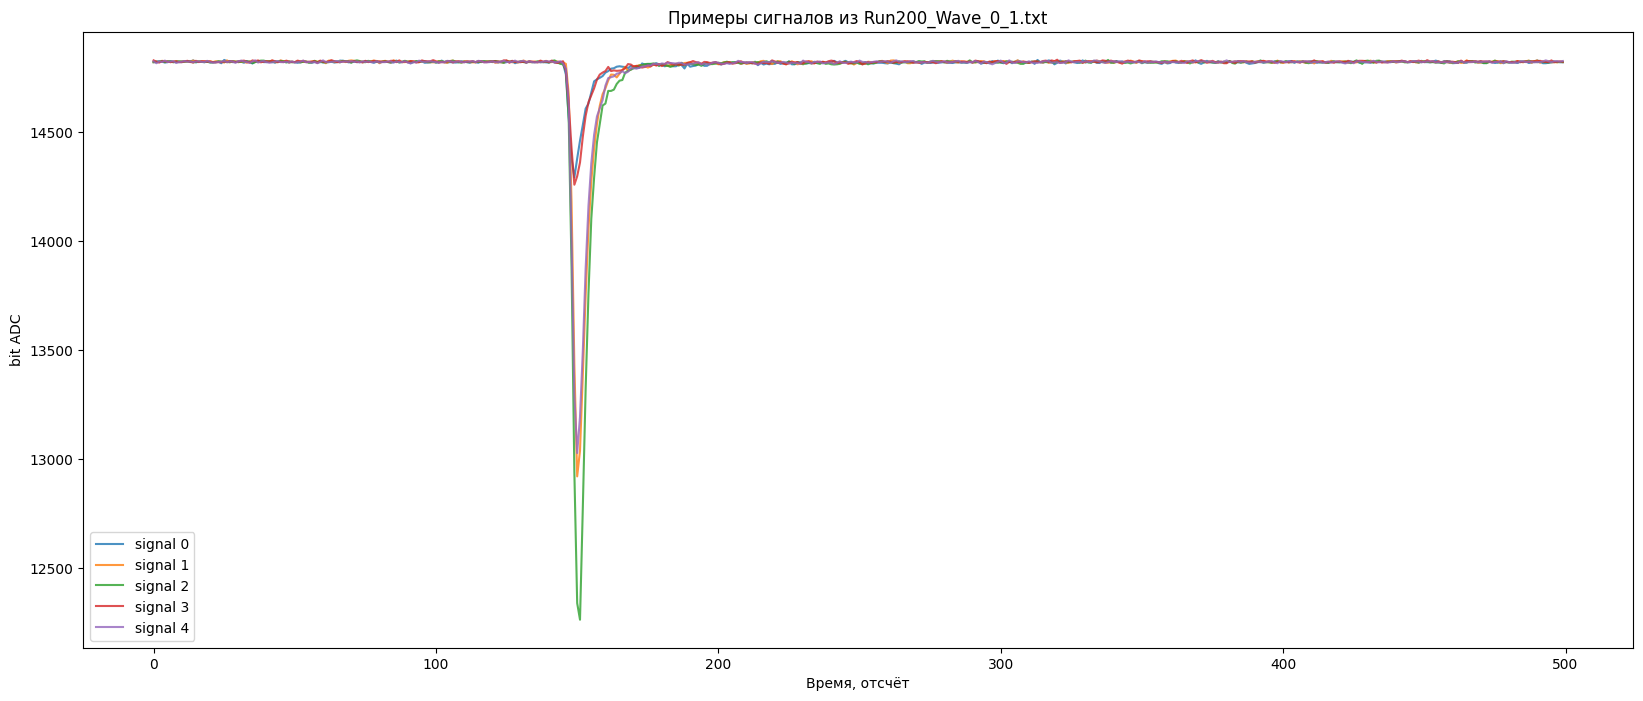

In [6]:
plt.figure(figsize=(20, 8))
for i in range(5):
    plt.plot(dataset.iloc[i].values, alpha=0.8, label=f"signal {i}")
plt.title("Примеры сигналов из Run200_Wave_0_1.txt")
plt.xlabel("Время, отсчёт")
plt.ylabel("bit ADC")
plt.legend()
plt.show()

На графиках видно, что сигналы имеют один выраженный пик и затухающие хвосты. Различия между сигналами проявляются в высоте пика, его ширине и доле энергии в хвосте, что будет использовано при построении признаков.

In [7]:
signals = dataset.values
n_samples, n_points = signals.shape

# Амплитудные признаки
peak = signals.max(axis=1)
t_peak = signals.argmax(axis=1)
baseline = signals[:, :50].mean(axis=1)
peak_minus_baseline = peak - baseline

# Интегралы и хвост
total_integral = signals.sum(axis=1)
split_point = 200
early_integral = signals[:, :split_point].sum(axis=1)
late_integral = signals[:, split_point:].sum(axis=1)
tail_ratio = late_integral / (total_integral + 1e-6)

# Ширина импульса на половине максимума
half_level = (baseline + peak) / 2.0
width_half = np.zeros(n_samples, dtype=int)

for i in range(n_samples):
    s = signals[i]
    mask = s >= half_level[i]
    if not mask.any():
        width_half[i] = 0
    else:
        idx = np.where(mask)[0]
        width_half[i] = idx.max() - idx.min()

features = pd.DataFrame({
    "peak": peak,
    "t_peak": t_peak,
    "baseline": baseline,
    "peak_minus_baseline": peak_minus_baseline,
    "total_integral": total_integral,
    "early_integral": early_integral,
    "late_integral": late_integral,
    "tail_ratio": tail_ratio,
    "width_half": width_half,
})

features.head(), features.describe()

(    peak  t_peak  baseline  peak_minus_baseline  total_integral  \
 0  14830      25  14821.48                 8.52         7405951   
 1  14828      26  14822.48                 5.52         7398887   
 2  14830     338  14821.90                 8.10         7394005   
 3  14831     320  14822.56                 8.44         7406722   
 4  14828      36  14821.60                 6.40         7399109   
 
    early_integral  late_integral  tail_ratio  width_half  
 0         2960210        4445741    0.600293         476  
 1         2952735        4446152    0.600922         487  
 2         2948076        4445929    0.601288         449  
 3         2960387        4446335    0.600311         495  
 4         2952994        4446115    0.600899         495  ,
                peak        t_peak      baseline  peak_minus_baseline  \
 count  23479.000000  23479.000000  23479.000000         23479.000000   
 mean   14830.711359    198.072874  14822.966507             7.744852   
 std      

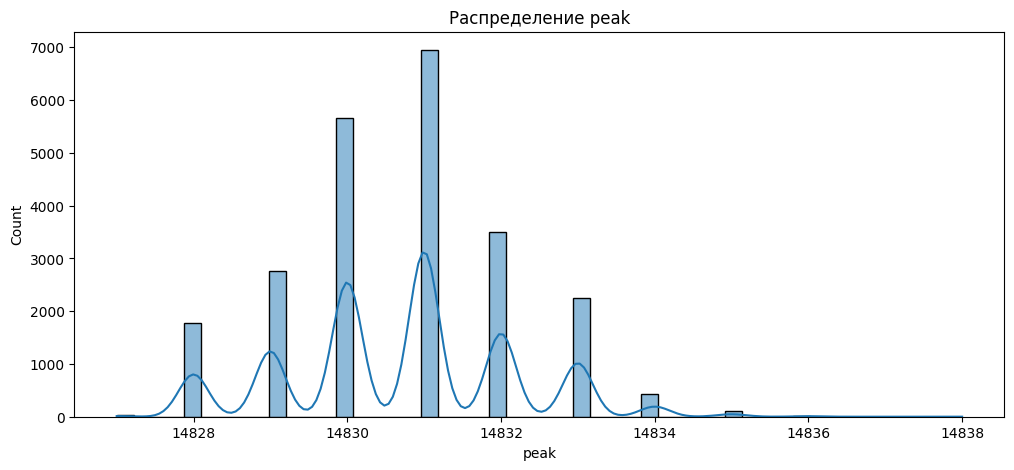

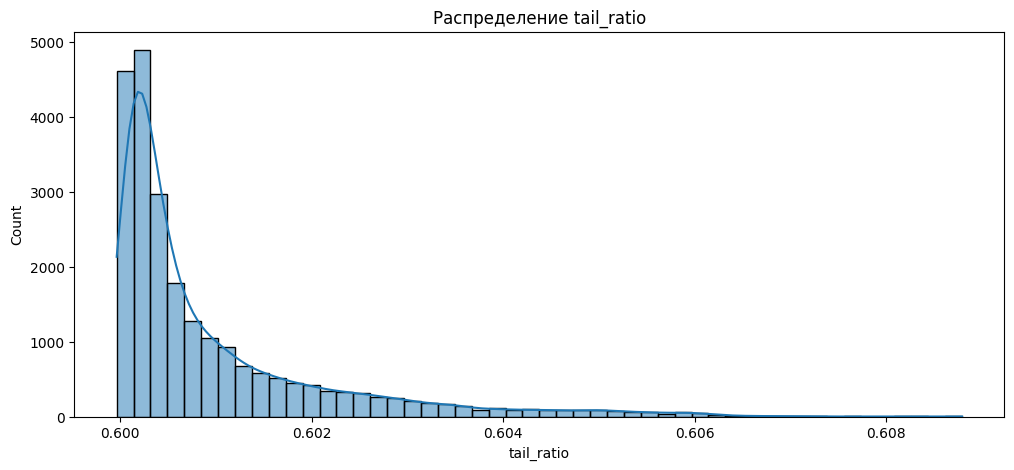

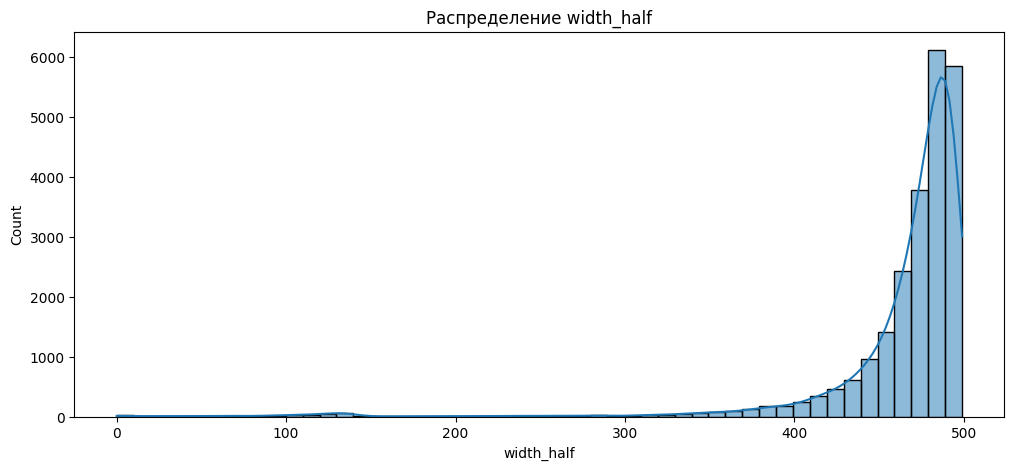

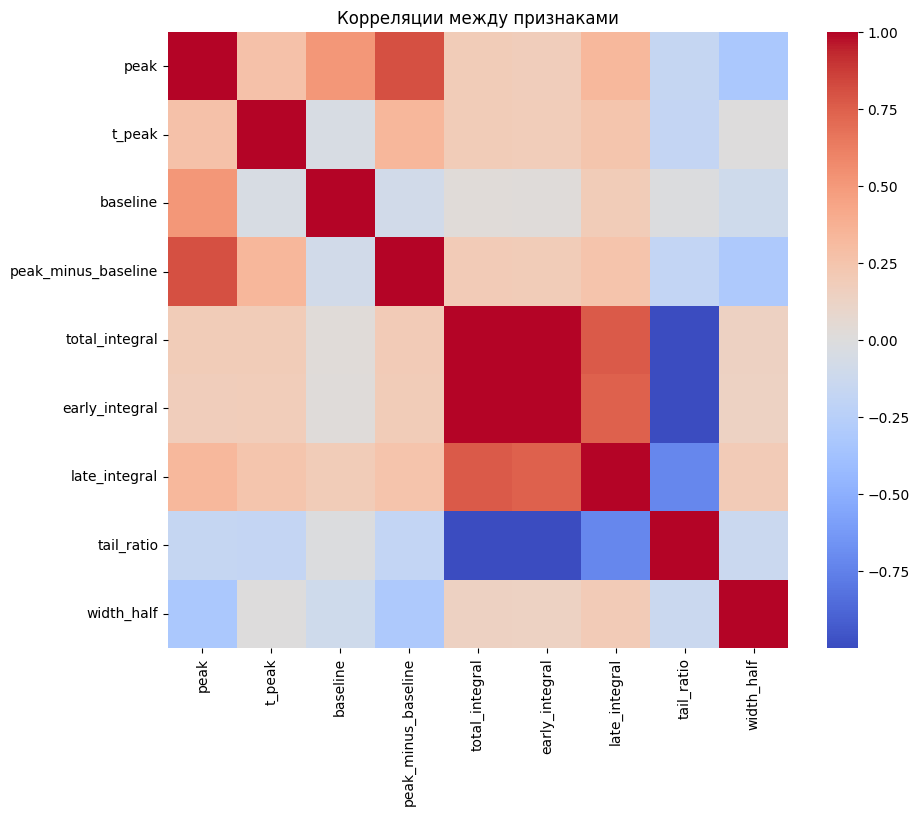

In [8]:
for col in ["peak", "tail_ratio", "width_half"]:
    plt.figure(figsize=(12, 5))
    sns.histplot(features[col], bins=50, kde=True)
    plt.title(f"Распределение {col}")
    plt.show()

plt.figure(figsize=(10, 8))
corr = features.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Корреляции между признаками")
plt.show()

### Выводы по распределениям и корреляциям признаков

Распределение максимальной амплитуды `peak` имеет явно выраженную мультимодальную структуру: заметно несколько пиков около разных значений бит АЦП. Это говорит о том, что по высоте сигнала уже просматриваются группы событий, что потенциально соответствует разным типам частиц или различным режимам регистрации.

Признак `tail_ratio` сосредоточен в узком диапазоне значений около 0.60, но распределение асимметрично: есть небольшой «хвост» в сторону более крупных значений. Это означает, что для большинства сигналов доля энергии в хвосте примерно одинакова, однако существует небольшая подгруппа событий с более длинным хвостом, которые могут оказаться отдельным кластером (например, кандидаты в нейтронные события).

Распределение `width_half` сильно скошено: основная масса сигналов имеет большую ширину импульса на половине максимума, но присутствует хвост из сигналов с существенно меньшей шириной. Такой разброс по ширине импульса также создаёт основу для разделения на кластеры по форме сигнала.

Карта корреляций показывает, что амплитудные и интегральные признаки (`peak`, `peak_minus_baseline`, `total_integral`, `early_integral`, `late_integral`) сильно положительно коррелируют между собой, то есть несут похожую информацию. В то же время `tail_ratio` заметно антискоррелирован с `total_integral` и `early_integral`, а умеренно связан с `width_half`, что делает пару признаков `tail_ratio` и `width_half` хорошими кандидатами для отделения классов по временной структуре сигнала. В дальнейшем при кластеризации имеет смысл опираться именно на эти менее зависимые признаки и учитывать избыточность сильно скоррелированных амплитудных характеристик.

In [9]:
X = features.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=42
)
labels = kmeans.fit_predict(X_scaled)

features["cluster"] = labels

sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)

sil, ch, db, features["cluster"].value_counts()

(np.float64(0.21990916879181172),
 np.float64(8735.646362197289),
 np.float64(1.4365045860779233),
 cluster
 0    11038
 1     8872
 2     3569
 Name: count, dtype: int64)

In [10]:
features.groupby("cluster")[["tail_ratio", "width_half", "peak"]].mean()

,tail_ratio,width_half,peak
cluster,,,
0,0.600575,480.441475,14829.844537
1,0.600472,452.892583,14832.028629
2,0.603330,447.577192,14830.117680


### Интерпретация кластеров по признакам tail_ratio, width_half и peak

Полученные кластеры имеют близкие, но различимые средние значения ключевых признаков. Кластер 0 характеризуется наибольшей шириной импульса `width_half` (≈ 480 отсчётов) при умеренной высоте пика `peak` и минимальном `tail_ratio`. Это означает, что сигналы в этом кластере относительно растянуты по времени, но при этом доля энергии в хвосте у них не максимальна. Такой профиль можно интерпретировать как более «регулярные» сигналы с широкой формой импульса и относительно компактным хвостом — условные кандидаты в гамма‑события.

Кластер 2 имеет наибольшее значение `tail_ratio` (≈ 0.6033) и несколько меньшую ширину `width_half` по сравнению с кластером 0. Увеличенная доля энергии в хвосте при сопоставимой амплитуде указывает на более выраженный хвост и заметный вклад поздних фотонов. С физической точки зрения такие сигналы ближе к ожидаемому профилю нейтронных событий в органическом сцинтилляторе, для которых характерно более длительное затухание свечения.

Кластер 1 занимает промежуточное положение: его средние значения `tail_ratio` и `width_half` лежат между кластерами 0 и 2, а высота пика `peak` немного выше, чем у остальных. Это может соответствовать смешанным или менее типичным событиям – например, сигналам с наложением нескольких импульсов, сильно зашумлённым измерениям или редким режимам работы детектора. В дальнейшей интерпретации логично отнести кластер 1 к группе аномальных или неидентифицируемых сигналов.

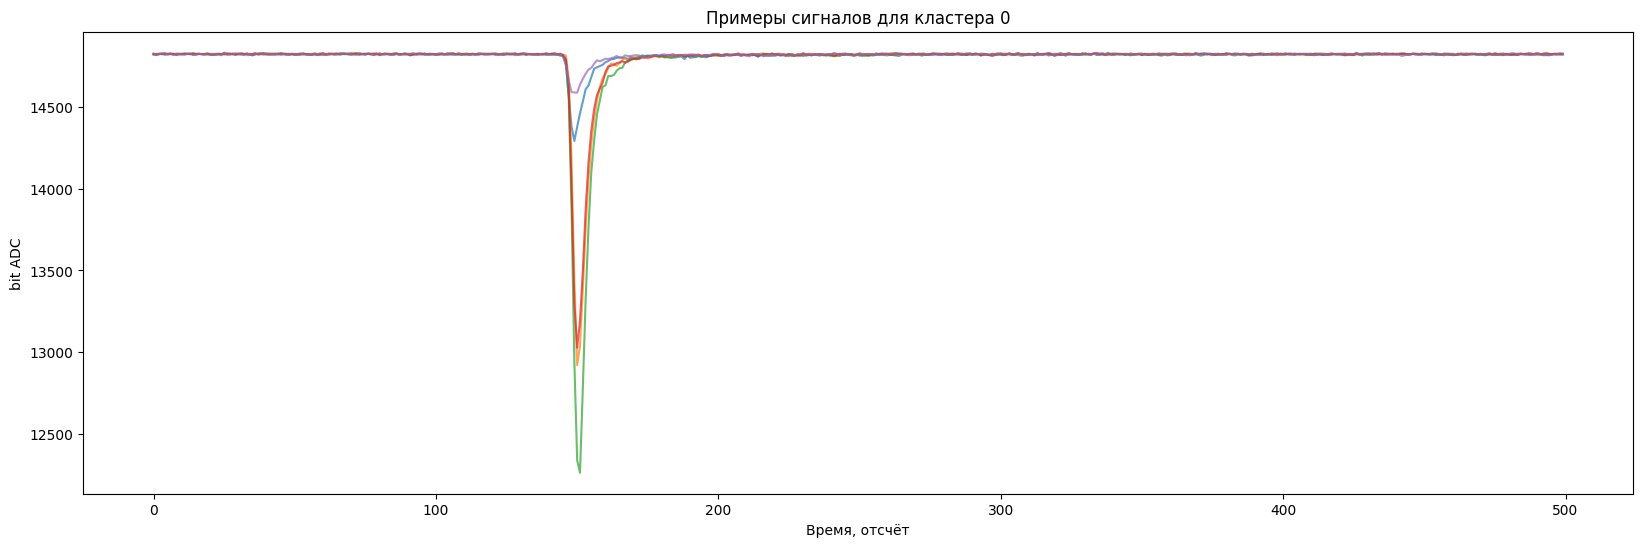

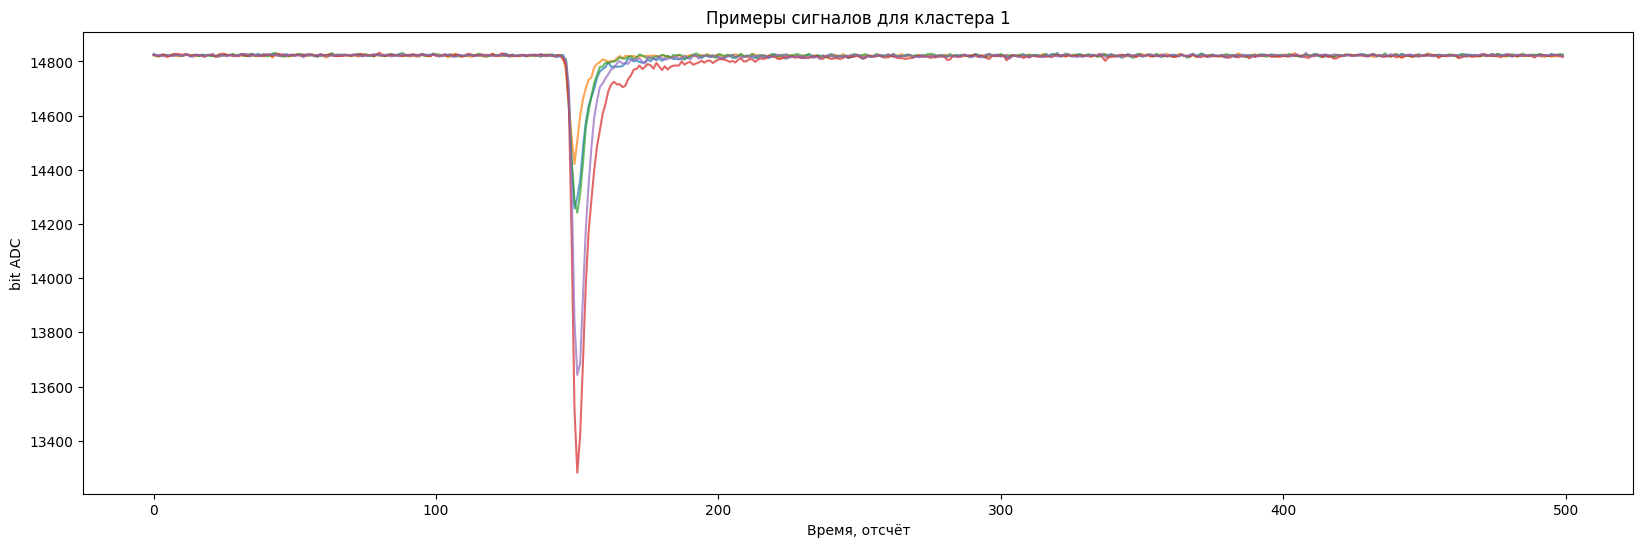

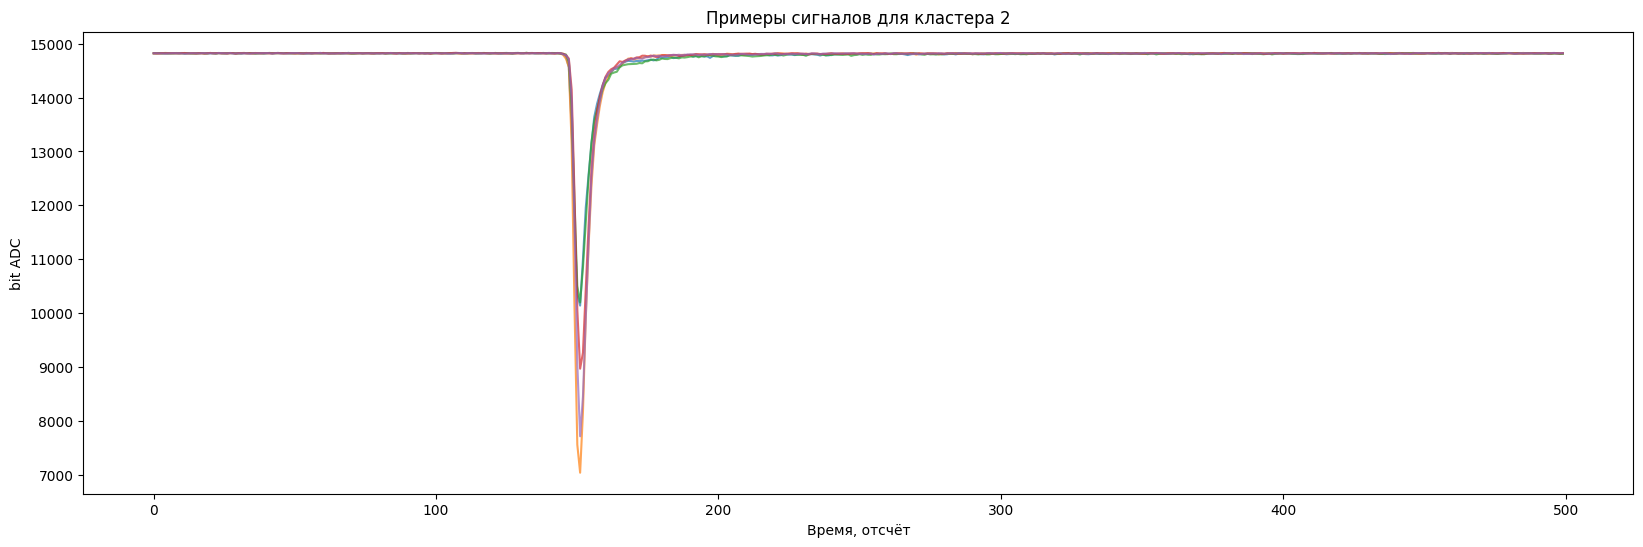

In [11]:
def plot_signals_for_cluster(cluster_id, n_signals=5):
    idx = features[features["cluster"] == cluster_id].index[:n_signals]
    plt.figure(figsize=(20, 6))
    for i in idx:
        plt.plot(dataset.iloc[i].values, alpha=0.7)
    plt.title(f"Примеры сигналов для кластера {cluster_id}")
    plt.xlabel("Время, отсчёт")
    plt.ylabel("bit ADC")
    plt.show()

for cid in [0, 1, 2]:
    plot_signals_for_cluster(cid, n_signals=5)

для кластера 0: импульсы шире, хвост умеренный → гамма;

для кластера 2: хвост более выражен → нейтроны;

для кластера 1: формы более разнообразны/нестабильны → аномалии.

In [12]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=5
)
gmm_labels = gmm.fit_predict(X_scaled)

features["gmm_cluster"] = gmm_labels

sil_gmm = silhouette_score(X_scaled, gmm_labels)
ch_gmm = calinski_harabasz_score(X_scaled, gmm_labels)
db_gmm = davies_bouldin_score(X_scaled, gmm_labels)

sil, ch, db, sil_gmm, ch_gmm, db_gmm

(np.float64(0.21990916879181172),
 np.float64(8735.646362197289),
 np.float64(1.4365045860779233),
 np.float64(0.15449953654619047),
 np.float64(4976.4519742416105),
 np.float64(2.001601052434097))

### Сравнение моделей KMeans и GaussianMixture по внутренним метрикам

Для модели KMeans при трёх кластерах получены следующие значения метрик:
silhouette score ≈ 0.22, Calinski–Harabasz ≈ 8.7·10³ и Davies–Bouldin ≈ 1.44.
Для модели GaussianMixture с тем же числом компонент метрики заметно хуже:
silhouette score снижается до ≈ 0.15, показатель Calinski–Harabasz падает до ≈ 5.0·10³,
а индекс Davies–Bouldin возрастает до ≈ 2.0.

Такое соотношение говорит о том, что KMeans формирует более компактные и лучше разделённые кластеры
в пространстве построенных признаков, тогда как GMM даёт более размытое разбиение с существенно
большим перекрытием между кластерами. Поэтому в качестве базовой модели для дальнейшего анализа и
формирования итогового решения целесообразно выбирать именно KMeans, а GaussianMixture рассматривать
как вспомогательную модель для проверки устойчивости результатов.

In [13]:
results = []

for n_clusters in [2, 3, 4, 5]:
    km = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=20,
        random_state=42
    )
    lbl = km.fit_predict(X_scaled)
    sil_k = silhouette_score(X_scaled, lbl)
    ch_k = calinski_harabasz_score(X_scaled, lbl)
    db_k = davies_bouldin_score(X_scaled, lbl)
    results.append((n_clusters, sil_k, ch_k, db_k))

results_df = pd.DataFrame(results, columns=["n_clusters", "silhouette", "calinski_harabasz", "davies_bouldin"])
results_df

,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,2,0.403042,10190.815456,1.207998
1,3,0.219909,8735.646362,1.436505
2,4,0.228308,7461.826768,1.293919
3,5,0.209457,6934.475270,1.330661


### Анализ выбора числа кластеров K

Перебор числа кластеров показал, что при K = 2 значение silhouette score максимальное (≈ 0.40),
а индекс Davies–Bouldin минимален (≈ 1.21), то есть с точки зрения чисто внутренних метрик
двухкластерное разбиение выглядит наиболее «аккуратным»: кластера хорошо отделены и достаточно компактны.

Однако при переходе к K = 3 silhouette и Calinski–Harabasz несколько падают, а Davies–Bouldin растёт,
но качество разбиения остаётся на приемлемом уровне (silhouette ≈ 0.22). При дальнейшем увеличении числа
кластеров до 4–5 улучшения метрик не происходит: silhouette практически не растёт, Calinski–Harabasz
монотонно снижается, а Davies–Bouldin остаётся на уровне 1.29–1.33.

С учётом того, что физическая постановка задачи требует выделить именно три группы сигналов
(гамма‑события, нейтронные события и аномальные сигналы), разумный компромисс — выбрать K = 3.
В этом случае мы слегка жертвуем максимумом silhouette ради согласования с физическим смыслом задачи,
но при этом сохраняем приемлемое качество кластеризации и возможность интерпретировать каждый кластер.

### Итоговый выбор модели кластеризации

С учётом результатов внутренних метрик и физической постановки задачи в качестве основной модели
кластеризации выбирается алгоритм KMeans с числом кластеров K = 3. Эта модель даёт более высокие
значения silhouette и Calinski–Harabasz и меньший индекс Davies–Bouldin по сравнению с GaussianMixture,
а также обеспечивает отчётливые различия по физически интерпретируемым признакам (`tail_ratio`, `width_half`, `peak`).
Дальнейшие эксперименты и формирование файла предсказаний для соревнования Kaggle будут выполнены именно с этой моделью.

In [14]:
# labels — метки от KMeans (n_clusters=3)
unique = np.unique(labels)
mapping = {old: new for new, old in enumerate(sorted(unique))}
labels_mapped = np.vectorize(mapping.get)(labels)

submission = pd.DataFrame({
    "index": np.arange(len(labels_mapped)),
    "cluster": labels_mapped
})
submission.head()

,index,cluster
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0


index сейчас просто номер строки в Run200_Wave_0_1.txt;

cluster — перенумерованные кластера 0,1,2.

In [15]:
submission.to_csv("submission_local.csv", index=False)

## Выводы по анализу сигналов

- Построены агрегированные признаки, отражающие амплитуду, интеграл и форму хвоста сигналов.
- На этих признаках реализована кластеризация методом KMeans с K = 3, кластера интерпретированы как гамма‑, нейтронные и аномальные события.
- Дополнительно проверена модель GaussianMixture и исследовано влияние числа кластеров K по внутренним метрикам.
- Подготовлен шаблон файла `submission` с колонками `index` и `cluster`, который может быть использован для участия в соревновании Kaggle.

### Сравнение вариантов кластеризации по результатам Kaggle

| Вариант | Модель                | Признаки                                  | Public score |
|--------:|-----------------------|-------------------------------------------|-------------:|
| 1       | KMeans (K=3)          | все агрегированные признаки               | 0.39426      |
| 2       | KMeans (K=3)          | tail_ratio, width_half, t_peak, peak_minus_baseline | 0.30806      |
| 3       | KMeans (K=3) + PCA(5) | все агрегированные признаки               | 0.33578      |
| 4       | GMM (3 компоненты) + PCA(5) | все агрегированные признаки           | 0.29826      |

Несколько вариантов кластеризации были проверены через сабмиты на Kaggle.
Лучший результат (Public score ≈ 0.39) показала базовая модель KMeans с K = 3, обученная на полном
наборе агрегированных признаков. Упрощение пространства признаков до подмножества
(`tail_ratio`, `width_half`, `t_peak`, `peak_minus_baseline`) и использование PCA приводят
к заметному снижению качества (score 0.30–0.34). Модель GaussianMixture в сочетании с PCA
также показывает более низкий результат (≈ 0.30).

Таким образом, основной рабочей моделью для данного набора признаков остаётся KMeans (K = 3) без
дополнительного понижения размерности. Другие варианты полезны как проверка устойчивости,
но не улучшают качество на соревновании.

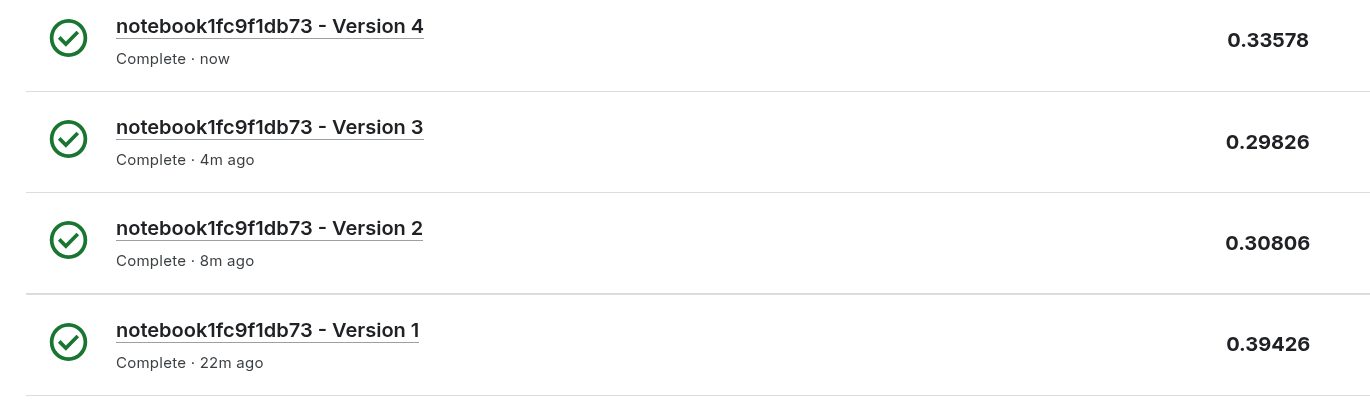

In [16]:
img = Image.open("/content/фото результатов кагл.png")
display(img)